In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train = pd.read_csv("train.csv")
formula_train = pd.read_csv("formula_train.csv")

print(f"Train dataset shape: {train.shape}")
print(f"Train_formula dataset shape: {formula_train.shape}")

Train dataset shape: (17010, 82)
Train_formula dataset shape: (17010, 88)


In [3]:
test = pd.read_csv("test.csv")
formula_test = pd.read_csv("formula_test.csv")

print(f"Test dataset shape: {test.shape}")
print(f"Test_formula dataset shape: {formula_test.shape}")

Test dataset shape: (4253, 81)
Test_formula dataset shape: (4253, 87)


In [4]:
train.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [5]:
formula_train.head()

,H,He,Li,Be,B,C,N,O,F,Ne,...,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
0,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,29.0,Ba0.2La1.8Cu1O4
1,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,26.0,Ba0.1La1.9Ag0.1Cu0.9O4
2,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,19.0,Ba0.1La1.9Cu1O4
3,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,22.0,Ba0.15La1.85Cu1O4
4,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,23.0,Ba0.3La1.7Cu1O4


In [6]:
print("Number of missing values in train datasets:")
print(train.isna().sum())
print(formula_train.isna().sum())

Number of missing values in train datasets:
number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
critical_temp            0
Length: 82, dtype: int64
H                0
He               0
Li               0
Be               0
B                0
                ..
Po               0
At               0
Rn               0
critical_temp    0
material         0
Length: 88, dtype: int64


In [7]:
print("Number of missing values in test datasets:")
print(test.isna().sum())
print(formula_test.isna().sum())

Number of missing values in test datasets:
number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
wtd_entropy_Valence      0
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
Length: 81, dtype: int64
H           0
He          0
Li          0
Be          0
B           0
           ..
Bi          0
Po          0
At          0
Rn          0
material    0
Length: 87, dtype: int64


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17010 entries, 0 to 17009
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               17010 non-null  int64  
 1   mean_atomic_mass                 17010 non-null  float64
 2   wtd_mean_atomic_mass             17010 non-null  float64
 3   gmean_atomic_mass                17010 non-null  float64
 4   wtd_gmean_atomic_mass            17010 non-null  float64
 5   entropy_atomic_mass              17010 non-null  float64
 6   wtd_entropy_atomic_mass          17010 non-null  float64
 7   range_atomic_mass                17010 non-null  float64
 8   wtd_range_atomic_mass            17010 non-null  float64
 9   std_atomic_mass                  17010 non-null  float64
 10  wtd_std_atomic_mass              17010 non-null  float64
 11  mean_fie                         17010 non-null  float64
 12  wtd_mean_fie      

In [9]:
formula_train = formula_train.drop(columns=['critical_temp'])
train = pd.concat([train, formula_train], axis=1)

In [10]:
train.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn,material
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.2La1.8Cu1O4
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.1La1.9Ag0.1Cu0.9O4
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.1La1.9Cu1O4
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.15La1.85Cu1O4
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,Ba0.3La1.7Cu1O4


In [11]:
train.drop(columns=['material'], inplace=True)

In [12]:
train.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


In [13]:
X = train.drop(columns=['critical_temp'])
y = train['critical_temp']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (17010, 167)
Target shape: (17010,)


In [14]:
# from sklearn.decomposition import PCA

# # PCA автоматически убирает линейные зависимости
# pca = PCA(n_components=0.99)  # сохраняем 95% дисперсии
# X_pca = pca.fit_transform(X)

# print(f"PCA уменьшил размерность до: {X_pca.shape[1]} компонент")

In [31]:
test = pd.concat([test, formula_test], axis=1)

print(f"Full Test dataset shape: {test.shape}")

Full Test dataset shape: (4253, 255)


In [33]:
test.drop(columns=['material'], inplace=True)

In [35]:
test.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn
0,5,92.729214,61.051113,73.132787,37.513930,1.449309,1.146919,122.90607,35.741099,47.094633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,4,64.632217,55.790060,48.775792,35.178830,1.139875,0.931491,122.90607,35.851917,46.059083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,4,76.444563,65.834647,59.356672,48.955994,1.199541,1.241867,121.32760,22.132267,43.823354,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
3,4,96.032850,77.279467,69.515930,53.611120,1.159784,1.267452,151.25960,22.543367,59.663892,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,4,96.451652,75.978308,69.689342,53.146925,1.158346,1.259726,152.93481,24.421050,60.166149,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


In [37]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17010 entries, 0 to 17009
Columns: 168 entries, number_of_elements to Rn
dtypes: float64(156), int64(12)
memory usage: 21.8 MB


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (11907, 167), (11907,)
Test dataset size: (5103, 167), (5103,)


In [40]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
y_pred = model.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

Mean Absolute Error: 12.995764895288458
Mean Squared Error: 1473.897036960468
R2: -0.2339842531687486


In [47]:
print('w1, ..., w167: ', model.coef_)
print('w0:', model.intercept_)

w1, ..., w167:  [ 1.04038146e+00  9.27453942e-01 -1.35278593e+00 -4.57524519e-01
  8.33323393e-01 -3.10721602e+01  8.43416456e-01  1.55788695e-01
  1.00424474e-01 -4.47282247e-01  4.39675838e-02 -1.24919963e-01
  1.32361190e-02  1.08857507e-01  3.64733266e-02 -2.49100647e+01
  6.17833392e+01  3.08980692e-02  1.78045541e-02 -3.74164592e-02
 -7.06358491e-02 -9.42103463e-01  2.90434349e+00  7.57004994e-01
 -2.63242916e+00 -1.66095153e+01  2.05286277e+01  1.16944560e-01
 -7.78011531e-02 -3.41297642e-01 -1.37312943e-01 -5.34693418e-03
  4.23222055e-03  1.31810536e-04  3.79668388e-04 -9.57590979e-01
  4.60119365e-01 -1.04076416e-03 -5.00514091e-04  3.28845602e-03
 -8.70406308e-04 -3.28857099e-02  3.09179962e-01  1.04113079e-01
 -3.88816766e-01  1.18260269e+01 -2.08852316e+01 -3.07371153e-01
 -6.82150846e-02  1.10379577e+00 -4.89846438e-01  1.20689785e+00
 -1.92989616e+00 -9.24848157e-01  1.51919993e+00 -1.64040442e+01
  1.81257086e+01 -1.27437243e-01  4.94171007e-01 -8.38025113e-01
  7.32772

In [49]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

num_folds = 5
seed = 7

kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)

scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')

print(scores)
print(-scores.mean())

[ -277.32779417  -956.15505286 -1767.57537128  -295.80183012
  -261.66117223]
711.704244131947


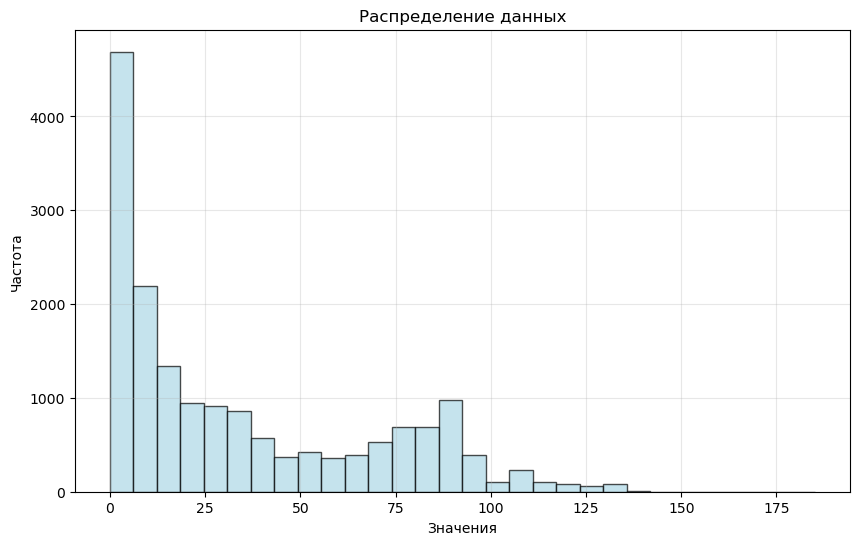

In [50]:
plt.figure(figsize=(10, 6))
plt.hist(train['critical_temp'], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
plt.title('Распределение данных')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()


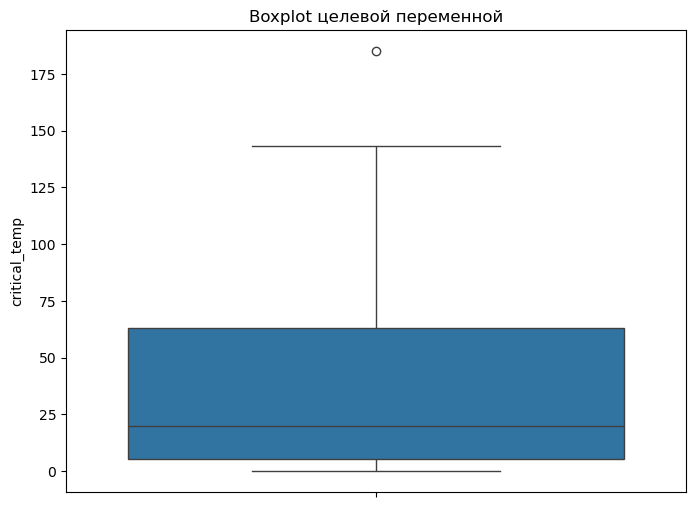

In [53]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=y)
plt.title('Boxplot целевой переменной')
plt.show()

In [57]:
def count_outliers_iqr(df):
    outliers_count = {}
    
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outliers_count[column] = len(outliers)
    
    return pd.Series(outliers_count)

outliers_iqr = count_outliers_iqr(X)
print("Количество выбросов по IQR:")
print(sorted(outliers_iqr))

Количество выбросов по IQR:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 3, 6, 7, 7, 10, 11, 19, 28, 32, 34, 36, 45, 51, 68, 76, 79, 82, 117, 121, 123, 124, 124, 135, 135, 141, 143, 148, 152, 161, 175, 178, 191, 191, 196, 203, 235, 235, 235, 235, 236, 237, 239, 241, 250, 258, 265, 283, 283, 292, 294, 303, 314, 315, 317, 344, 362, 368, 376, 400, 405, 412, 423, 425, 432, 435, 439, 444, 458, 467, 471, 473, 473, 514, 521, 535, 537, 542, 543, 584, 588, 595, 606, 627, 661, 666, 670, 682, 701, 721, 734, 748, 776, 821, 908, 921, 956, 956, 967, 999, 999, 1014, 1022, 1028, 1031, 1112, 1139, 1148, 1169, 1184, 1187, 1194, 1205, 1208, 1246, 1285, 1315, 1331, 1400, 1458, 1495, 1552, 1667, 1691, 1761, 1764, 1826, 1857, 1893, 1953, 2104, 2315, 2668, 2727, 2753, 2768, 3254, 3314, 3878]


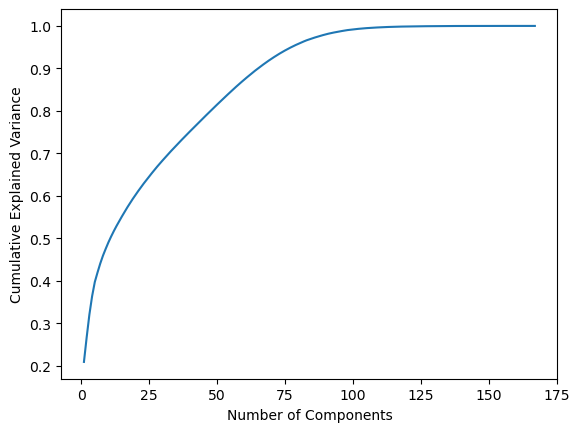

In [63]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [65]:
pca = PCA(n_components=110)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

In [67]:
X_pca = pd.DataFrame(
    data=X_pca,
    columns=[f'PC_{i+1}' for i in range(110)]
)

X_pca

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_101,PC_102,PC_103,PC_104,PC_105,PC_106,PC_107,PC_108,PC_109,PC_110
0,3.532425,-0.837423,-2.983549,1.610817,-0.203190,0.237742,0.678426,-0.251056,-0.175088,0.046423,...,-0.238868,-0.030620,0.117340,0.119788,0.031184,-0.013864,-0.122728,0.071685,0.022330,0.076713
1,4.392974,0.163820,-1.614423,1.065611,0.580277,0.941041,0.013623,0.041628,-0.048612,0.858829,...,0.147802,0.150351,0.089882,0.154253,-0.104083,-0.041045,-0.226248,-0.113880,0.138873,-0.124057
2,3.352388,-0.891909,-3.066564,1.702473,-0.175984,0.259148,0.715827,-0.089168,-0.306458,0.055757,...,-0.199236,-0.017690,0.072313,0.167241,0.083411,0.020298,-0.162088,0.153886,0.015416,0.030933
3,3.447245,-0.861897,-3.021412,1.655029,-0.189856,0.249167,0.695710,-0.173282,-0.239218,0.051405,...,-0.219424,-0.024773,0.097191,0.141162,0.057360,0.002173,-0.140946,0.110494,0.018859,0.054765
4,3.682057,-0.799981,-2.923810,1.529539,-0.229119,0.211570,0.649942,-0.393174,-0.053337,0.035369,...,-0.276577,-0.039538,0.147452,0.087168,-0.021179,-0.041308,-0.092839,0.004118,0.029248,0.116025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17005,-2.583125,0.214852,1.746963,-2.690438,2.724319,1.476258,0.045566,-0.751219,1.767289,-1.356745,...,0.054248,-0.439815,0.298025,-0.178297,0.242322,0.561131,-0.028379,0.018565,0.054991,-0.589066
17006,5.955550,1.175902,-1.546380,-0.536952,1.259692,-0.799210,1.220587,0.095171,1.829380,-0.020695,...,0.079736,-0.068138,0.072777,-0.168779,0.320773,-0.252364,-0.069909,0.048600,-0.025631,0.048432
17007,-10.475255,1.139099,-1.726130,-0.361165,-0.278664,0.998412,-0.712636,-0.188557,0.102226,-0.474972,...,-0.247860,-0.337592,-0.051046,-0.203453,-0.178781,-0.208742,0.300379,0.007550,-0.104434,-0.243640
17008,-9.789606,1.187587,-1.307737,-0.816578,-0.952735,0.413719,-0.663445,-1.293785,0.890205,-0.157003,...,-0.245262,-0.354048,-0.065190,-0.048079,-0.159170,-0.199428,0.189676,0.157545,0.046224,-0.166203


In [69]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X, y, test_size=0.3)
model = LinearRegression()
model.fit(X_train_pca, y_train)

LinearRegression()

In [71]:
y_pred = model.predict(X_test_pca)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

Mean Absolute Error: 12.457371536659295
Mean Squared Error: 285.00133737646524
R2: 0.7600689648028349


In [79]:
num_folds = 5
seed = 7

kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)

model = LinearRegression()
scores = cross_val_score(model, X_pca, y, cv=kfold, scoring='neg_mean_squared_error')

print(scores)
print(-scores.mean())

[ -307.5346483   -953.35147124 -1154.38616779  -328.73497552
  -284.98750892]
605.7989543538491


In [99]:
from sklearn.feature_selection import RFE, RFECV
rfe = RFECV(
    estimator=LinearRegression(),
    cv=5,
    scoring='neg_mean_squared_error',
    min_features_to_select=120
)
rfe.fit(X, y)

print(f"Оптимальное количество признаков: {rfe.n_features_}")
print(f"Лучшие признаки: {X.columns[rfe.support_].tolist()}")

X_rfe_selected = X.loc[:, rfe.support_]

Оптимальное количество признаков: 122
Лучшие признаки: ['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'std_atomic_mass', 'mean_fie', 'gmean_fie', 'entropy_fie', 'wtd_entropy_fie', 'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius', 'wtd_gmean_atomic_radius', 'entropy_atomic_radius', 'wtd_entropy_atomic_radius', 'range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius', 'entropy_Density', 'wtd_entropy_Density', 'wtd_mean_ElectronAffinity', 'gmean_ElectronAffinity', 'wtd_gmean_ElectronAffinity', 'entropy_ElectronAffinity', 'wtd_entropy_ElectronAffinity', 'range_ElectronAffinity', 'std_ElectronAffinity', 'wtd_std_ElectronAffinity', 'mean_FusionHeat', 'wtd_mean_FusionHeat', 'gmean_FusionHeat', 'wtd_gmean_FusionHeat', 'entropy_FusionHeat', 'wtd_entropy_FusionHeat', 'range_FusionHeat', 'wtd_range_FusionHeat', 'std_FusionHeat', '

In [100]:
num_folds = 5
seed = 7

kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)

model = LinearRegression()
scores = cross_val_score(model, X_rfe_selected, y, cv=kfold, scoring='neg_mean_squared_error')

print(scores)
print(-scores.mean())

[ -283.94564783  -284.51559477 -1595.00817093  -300.75464714
  -267.87210714]
546.4192335648324


In [103]:
model = LinearRegression()
model.fit(X_rfe_selected, y)

LinearRegression()

In [105]:
selected_features = X.columns[rfe.support_].tolist()
y_pred = model.predict(test[selected_features])

submission_df = pd.DataFrame({
    'index': range(len(y_pred)),
    'critical_temp': y_pred
})

submission_df.to_csv('submission.csv', index=False)

In [95]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=20,
    direction='forward',
    cv=5
)
sfs_forward.fit(X, y)
X_forward_selected = X.loc[:, sfs_forward.get_support()]
X_forward_selected

,number_of_elements,wtd_mean_ElectronAffinity,entropy_ElectronAffinity,wtd_std_FusionHeat,wtd_gmean_ThermalConductivity,std_ThermalConductivity,wtd_std_ThermalConductivity,mean_Valence,wtd_gmean_Valence,C,Si,V,Ge,Sr,Ag,Ba,Ce,Lu,Hg,Tl
0,4,111.727143,1.159687,4.666920,0.621979,168.854244,138.517163,2.25,2.219783,0.0,0.0,0.0,0.0,0.0,0.0,0.20,0.0,0.00,0.0,0.0
1,5,112.316429,1.427997,4.603000,0.619735,198.554600,139.630922,2.00,2.210679,0.0,0.0,0.0,0.0,0.0,0.1,0.10,0.0,0.00,0.0,0.0
2,4,112.213571,1.159687,4.649635,0.619095,168.854244,138.540613,2.25,2.232679,0.0,0.0,0.0,0.0,0.0,0.0,0.10,0.0,0.00,0.0,0.0
3,4,111.970357,1.159687,4.658301,0.620535,168.854244,138.528893,2.25,2.226222,0.0,0.0,0.0,0.0,0.0,0.0,0.15,0.0,0.00,0.0,0.0
4,4,111.240714,1.159687,4.684014,0.624878,168.854244,138.493671,2.25,2.206963,0.0,0.0,0.0,0.0,0.0,0.0,0.30,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17005,4,86.511111,1.164382,17.657417,95.001493,55.056789,46.595943,3.25,3.519911,0.0,5.0,0.0,0.0,0.0,0.0,0.00,0.0,0.16,0.0,0.0
17006,5,100.490952,1.112639,5.204855,1.577047,151.164639,156.558695,2.20,2.038991,0.0,0.0,0.0,0.0,0.0,0.0,2.00,0.0,0.00,0.0,1.0
17007,2,81.120000,0.667182,4.040000,57.038314,8.500000,6.800000,4.50,4.781762,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0
17008,2,77.556000,0.667182,4.671182,58.781651,8.500000,7.862385,4.50,4.665819,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0


In [96]:
num_folds = 5
seed = 7

kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)

model = LinearRegression()
scores = cross_val_score(model, X_forward_selected, y, cv=kfold, scoring='neg_mean_squared_error')

print(scores)
print(-scores.mean())

[-366.09220057 -381.35149984 -421.59292092 -397.12582934 -357.17100877]
384.666691889399


In [ ]:
from sklearn.ensemble import BaggingRegressor

bagging_model = BaggingRegressor(
    estimator=LinearRegression(),
    n_estimators=10,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42,
    n_jobs=-1
)

In [ ]:
bagging_model.fit(X_train, y_train)

# Предсказание
y_pred = bagging_model.predict(X_test)

# Оценка качества
print("=== БЭГГИНГ НА LINEAR REGRESSION ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.5,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred_gb):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_gb):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_gb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}")

# Важность признаков
feature_importance = gb_model.feature_importances_

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

# Обучение с валидацией
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")

y_pred = xgb_model.predict(test)
submission = pd.DataFrame({
    'index': test.index,
    'critical_temp': y_pred
})

submission.to_csv('superconductor_predictions.csv', index=False)

# Просмотр первых строк
print(submission.head())

In [ ]:
features = test.columns

In [ ]:
coeff_df = pd.DataFrame(model.coef_, columns=['Coefficient'])
coeff_df['features'] = features
coeff_df_selected = coeff_df[(coeff_df['Coefficient'] > -1e-13) & (coeff_df['Coefficient'] < 1e-13)]

coeff_df_selected.sort_values(by='Coefficient')

In [ ]:
features_to_drop = coeff_df_selected['features'].tolist()
print(f"Признаки для удаления ({len(features_to_drop)}):", features_to_drop)

In [ ]:
X_reduced = X.drop(columns=features_to_drop)

print(f"Исходная размерность: {X.shape}")
print(f"После удаления: {X_reduced.shape}")

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

num_folds = 5
seed = 7

kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)

model = LinearRegression()
scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')

print(scores)
print(scores.mean())

In [ ]:
X_train_red, X_test_red, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3)

print(f'Train dataset size: {X_train_red.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test_red.shape}, {y_test.shape}')

In [ ]:
model = LinearRegression()

# model.fit(X_train_red, y_train)

y_log = np.log1p(y_train)
model.fit(X_train_red, y_log)

In [ ]:
# y_pred_red = model.predict(X_test_red)
y_pred_log = model.predict(X_test_red)
y_pred = np.expm1(y_pred_log) 

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 6))
plt.hist(train['critical_temp'], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
plt.title('Распределение данных')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = model.predict(X_test_scaled)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))

In [ ]:
from sklearn.ensemble import BaggingRegressor

bagging_model = BaggingRegressor(
    estimator=LinearRegression(),  # базовый алгоритм
    n_estimators=10,             # количество моделей
    max_samples=0.7,              # размер подвыборки (80%)
    max_features=0.6,             # количество признаков (80%)
    bootstrap=True,               # бутстрэп выборки
    bootstrap_features=False,     # без бутстрэпа признаков
    random_state=42,
    n_jobs=-1                    # использовать все ядра
)

In [ ]:
bagging_model.fit(X_train, y_train)
y_pred = model.predict(X_test_scaled)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

In [ ]:
test.info()

In [ ]:
test

In [ ]:
def remove_high_correlation_features(X, threshold=0.95):
    corr_matrix = X.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = [column for column in upper_tri.columns 
               if any(upper_tri[column] > threshold)]
    
    return X.drop(columns=to_drop), to_drop

X_reduced, dropped_features = remove_high_correlation_features(X, threshold=0.95)
print(f"Было: {X.shape[1]}, стало: {X_reduced.shape[1]}")

In [ ]:
X_train_red, X_test_red, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train_red, y_train)

In [ ]:
y_pred = model.predict(X_test_red)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))